In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

In [2]:
train = pd.read_csv("train.csv", encoding="latin1")

descriptions = pd.read_csv(
    "product_descriptions.csv",
    encoding="latin1"
)

In [3]:
train = pd.merge(
    train,
    descriptions,
    on="product_uid",
    how="left"
)

In [4]:
train = train.sample(
    n=2000,
    random_state=42
).reset_index(drop=True)

In [5]:
train["search_term"] = (
    train["search_term"].str.lower()
)

train["product_title"] = (
    train["product_title"].str.lower()
)

train["product_description"] = (
    train["product_description"].str.lower()
)

In [6]:
def clean_text(text):

    text = re.sub(
        r'[^a-zA-Z0-9 ]',
        '',
        str(text)
    )

    return text

In [7]:
train["search_term"] = (
    train["search_term"].apply(clean_text)
)

train["product_title"] = (
    train["product_title"].apply(clean_text)
)

train["product_description"] = (
    train["product_description"].apply(clean_text)
)

In [8]:
train["query_length"] = (
    train["search_term"]
    .apply(len)
)

In [9]:
train["title_length"] = (
    train["product_title"]
    .apply(len)
)

In [10]:
def common_words(row):

    query_words = set(
        row["search_term"].split()
    )

    title_words = set(
        row["product_title"].split()
    )

    return len(
        query_words.intersection(
            title_words
        )
    )

In [11]:
train["common_words"] = (
    train.apply(
        common_words,
        axis=1
    )
)

In [12]:
train["combined_text"] = (
    train["search_term"] + " " +
    train["product_title"] + " " +
    train["product_description"]
)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

In [15]:
X_text = tfidf.fit_transform(
    train["combined_text"]
)

In [16]:
X_text.shape

(2000, 1000)

In [17]:
numerical_features = train[
    [
        "query_length",
        "title_length",
        "common_words"
    ]
]

In [18]:
import scipy.sparse as sp

In [19]:
X = sp.hstack(
    [
        X_text,
        numerical_features
    ]
)

In [20]:
X.shape

(2000, 1003)

In [21]:
y = train["relevance"]

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [26]:
rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [27]:
pred = rf.predict(X_test)

In [28]:
from sklearn.metrics import mean_squared_error

In [29]:
rmse = (
    mean_squared_error(
        y_test,
        pred
    ) ** 0.5
)

print("RMSE:", rmse)

RMSE: 0.5251559014011503


In [30]:
print(X.shape)
print(rmse)

(2000, 1003)
0.5251559014011503


In [31]:
import pandas as pd

feature_names = (
    list(tfidf.get_feature_names_out())
    + ["query_length", "title_length", "common_words"]
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

           Feature  Importance
1002  common_words    0.089689
1000  query_length    0.035312
642          paint    0.022122
14              20    0.019885
787          screw    0.018019
620            old    0.016935
108          black    0.014710
1001  title_length    0.014553
800         series    0.014526
502           just    0.014193
301        durable    0.012228
908            tip    0.012180
896         tested    0.011639
891           tape    0.010923
938           used    0.010602
82       available    0.010452
306         easily    0.010040
753     resistance    0.010000
564        masonry    0.009935
754      resistant    0.008339


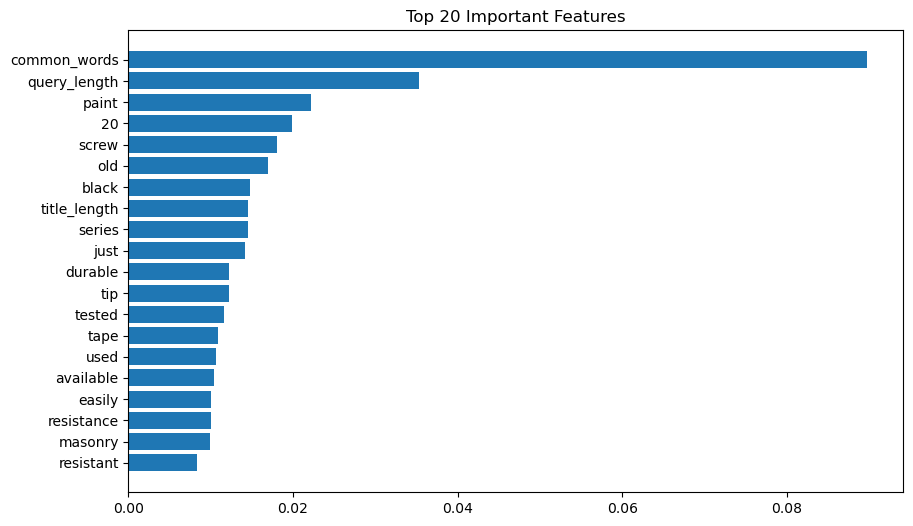

In [32]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [33]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 5.0 MB/s eta 0:00:21
   - -------------------------------------- 2.9/101.7 MB 9.4 MB/s eta 0:00:11
   - -------------------------------------- 5.0/101.7 MB 9.8 MB/s eta 0:00:10
   -- ------------------------------------- 7.1/101.7 MB 9.9 MB/s eta 0:00:10
   --- ------------------------------------ 9.4/101.7 MB 10.1 MB/s eta 0:00:10
   ---- ----------------------------------- 11.5/101.7 MB 10.2 MB/s eta 0:00:09
   ----- ---------------------------------- 14.2/101.7 MB 10.4 MB/s eta 0:00:09
   ------ --------------------------------- 16.0/101.7 MB 10.2 MB/s eta 0:00:09
   ------- -------------------------------- 18.4/101.7 MB 10.3 MB/s eta 0:00:09
   -------- ------------------------------- 20.4/101.7 MB 10.3 MB/s eta 0:00:08
   -------- ------------------------------- 22.8/101.7 MB 10.4 MB/s eta 0:00:08
   --------- ------------------------------ 24.6/101.7 MB 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [35]:
pred_xgb = xgb.predict(X_test)

rmse_xgb = (
    mean_squared_error(
        y_test,
        pred_xgb
    ) ** 0.5
)

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 0.5493233730639732


In [36]:
sample = train.sample(10)

In [39]:
X = X.tocsr()

In [40]:
type(X)

scipy.sparse._csr.csr_matrix

In [42]:
X[:10]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 434 stored elements and shape (10, 1003)>

In [43]:
sample_pred = rf.predict(
    X[:10]
)

In [44]:
sample = train.iloc[:10].copy()

In [45]:
sample["predicted_score"] = sample_pred

In [46]:
sample = sample.sort_values(
    by="predicted_score",
    ascending=False
)

In [47]:
sample[
    [
        "search_term",
        "product_title",
        "predicted_score"
    ]
]

,search_term,product_title,predicted_score
2,30 inch under cabinet stainless range hood,broan allure 2 series 30 in convertible range ...,2.585394
3,heat shrink tubing,gardner bender 12 in black polyolefin heat shr...,2.531786
8,black bench,ivy terrace 48 in black and black patio bench,2.495213
0,commercial cordless drill set,dewalt 20volt max lithiumion cordless combo ki...,2.488908
5,cargo mat,fanmats pittsburgh penguins heavy duty vinyl 3...,2.487706
4,stainless steel hardware,stainless glide stainless steel strap rolling ...,2.463126
6,ceiling hangers,global door controls ceiling hanger and 4 univ...,2.461385
9,cfl candelabra 100w,ecosmart 100w equivalent soft white 2700k spir...,2.444006
1,15 amp extension cord,cerrowire 15 amp 125volt stay plugged replacem...,2.409093
7,husky work bemch,husky mechanics tool set 185piece,2.239038


In [48]:
feature_names = (
    list(tfidf.get_feature_names_out())
    + ["query_length",
       "title_length",
       "common_words"]
)

In [49]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

In [50]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [51]:
print(
    importance.head(20)
)

           Feature  Importance
1002  common_words    0.089689
1000  query_length    0.035312
642          paint    0.022122
14              20    0.019885
787          screw    0.018019
620            old    0.016935
108          black    0.014710
1001  title_length    0.014553
800         series    0.014526
502           just    0.014193
301        durable    0.012228
908            tip    0.012180
896         tested    0.011639
891           tape    0.010923
938           used    0.010602
82       available    0.010452
306         easily    0.010040
753     resistance    0.010000
564        masonry    0.009935
754      resistant    0.008339


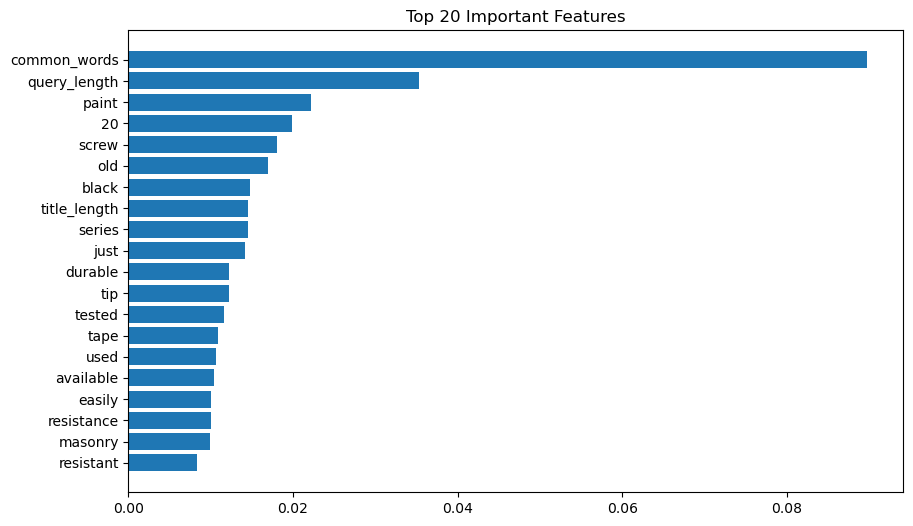

In [52]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Important Features"
)

plt.show()

In [53]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from xgboost import XGBRegressor

In [55]:
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

In [56]:
xgb.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [57]:
pred_xgb = xgb.predict(
    X_test
)

In [58]:
from sklearn.metrics import mean_squared_error

rmse_xgb = (
    mean_squared_error(
        y_test,
        pred_xgb
    ) ** 0.5
)

print(
    "XGBoost RMSE:",
    rmse_xgb
)

XGBoost RMSE: 0.547610764841751


In [59]:
print(rmse_xgb)

0.547610764841751


In [60]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
import lightgbm as lgb

In [62]:
group = (
    train.groupby("search_term")
    .size()
    .values
)

In [63]:
print(group[:10])

[1 1 1 1 1 1 1 1 1 1]


In [64]:
X = X.tocsr()

In [65]:
sample_pred = rf.predict(X[:10])

In [66]:
sample = train.iloc[:10].copy()

In [67]:
sample["predicted_score"] = sample_pred

In [68]:
sample = sample.sort_values(
    by="predicted_score",
    ascending=False
)

In [69]:
sample[
    [
        "search_term",
        "product_title",
        "relevance",
        "predicted_score"
    ]
]

,search_term,product_title,relevance,predicted_score
2,30 inch under cabinet stainless range hood,broan allure 2 series 30 in convertible range ...,2.67,2.585394
3,heat shrink tubing,gardner bender 12 in black polyolefin heat shr...,2.67,2.531786
8,black bench,ivy terrace 48 in black and black patio bench,3.00,2.495213
0,commercial cordless drill set,dewalt 20volt max lithiumion cordless combo ki...,3.00,2.488908
5,cargo mat,fanmats pittsburgh penguins heavy duty vinyl 3...,2.67,2.487706
4,stainless steel hardware,stainless glide stainless steel strap rolling ...,2.00,2.463126
6,ceiling hangers,global door controls ceiling hanger and 4 univ...,3.00,2.461385
9,cfl candelabra 100w,ecosmart 100w equivalent soft white 2700k spir...,1.67,2.444006
1,15 amp extension cord,cerrowire 15 amp 125volt stay plugged replacem...,2.67,2.409093
7,husky work bemch,husky mechanics tool set 185piece,1.67,2.239038


In [70]:
feature_names = (
    list(tfidf.get_feature_names_out())
    + [
        "query_length",
        "title_length",
        "common_words"
    ]
)

In [71]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

In [72]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [73]:
importance.head(20)

,Feature,Importance
1002,common_words,0.089689
1000,query_length,0.035312
642,paint,0.022122
14,20,0.019885
787,screw,0.018019
620,old,0.016935
108,black,0.014710
1001,title_length,0.014553
800,series,0.014526
502,just,0.014193


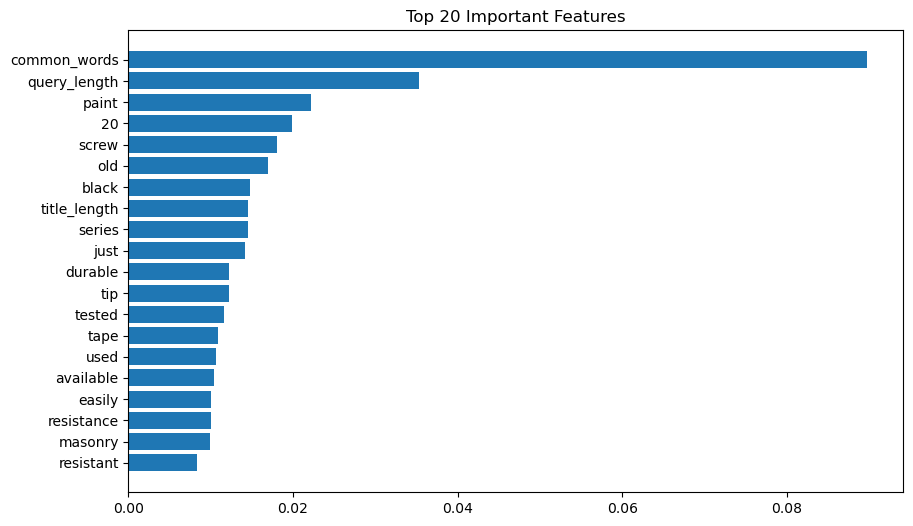

In [74]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Important Features"
)

plt.show()

In [75]:
import pickle

pickle.dump(
    rf,
    open(
        "search_ranking_model.pkl",
        "wb"
    )
)

In [76]:
pickle.dump(
    tfidf,
    open(
        "tfidf_vectorizer.pkl",
        "wb"
    )
)